Pre-exam checklist:

Run Cell 0 once while online to download NLTK data

pip install gensim rouge-score beforehand

python -m spacy download en_core_web_sm beforehand

For Lab 3 exams: only edit the Config cell — drop in the given corpus and test sentence, run all cells top to bottom

Lab 7 reuses Lab 6's preprocessed data — don't skip Lab 6 cells

## Tokenization, Stemming, Lemmatization

In [10]:
# ================================================================
# GLOBAL SETUP — Run this before anything else
# ================================================================
import warnings
warnings.filterwarnings('ignore')
import nltk

NLTK_RESOURCES = [
    'punkt', 'punkt_tab', 'averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng', 'universal_tagset',
    'wordnet', 'omw-1.4', 'stopwords', 'movie_reviews',
    'reuters', 'brown', 'maxent_ne_chunker', 'words'
]
for r in NLTK_RESOURCES:
    nltk.download(r, quiet=True)

print("NLTK resources ready.")

NLTK resources ready.


In [11]:
# ================================================================
# LAB 1 CONFIG — Edit only this cell
# ================================================================
FILE_PATH_L1   = None          # e.g. "my_text.txt" or None
INLINE_TEXT_L1 = """
Paste your text here. Must be at least 2000 words for full marks.
Repeat or expand if needed.
"""

In [12]:
# Load Text

def load_text(file_path=None, inline_text=None):
    if file_path:
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read()
        print(f"Loaded from file: {file_path}")
    else:
        text = inline_text.strip()
        print("Using inline text.")
    print(f"Characters : {len(text)}")
    print(f"Word count : {len(text.split())}")
    return text

text_l1 = load_text(FILE_PATH_L1, INLINE_TEXT_L1)

Using inline text.
Characters : 93
Word count : 18


In [13]:
# Tokenization

import spacy
from nltk.tokenize import word_tokenize, TreebankWordTokenizer

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import subprocess
    subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"], check=True)
    nlp = spacy.load("en_core_web_sm")

def tokenize_all(text):
    nltk_tokens     = word_tokenize(text)
    treebank_tokens = TreebankWordTokenizer().tokenize(text)
    spacy_tokens    = [t.text for t in nlp(text) if not t.is_space]

    print(f"\n{'Tokenizer':<28} Token Count")
    print("-" * 42)
    print(f"{'NLTK word_tokenize':<28} {len(nltk_tokens)}")
    print(f"{'NLTK TreebankWordTokenizer':<28} {len(treebank_tokens)}")
    print(f"{'spaCy':<28} {len(spacy_tokens)}")

    print(f"\nSample (NLTK)    : {nltk_tokens[:15]}")
    print(f"Sample (Treebank): {treebank_tokens[:15]}")
    print(f"Sample (spaCy)   : {spacy_tokens[:15]}")
    return nltk_tokens, treebank_tokens, spacy_tokens

nltk_tokens_l1, treebank_tokens_l1, spacy_tokens_l1 = tokenize_all(text_l1)


Tokenizer                    Token Count
------------------------------------------
NLTK word_tokenize           21
NLTK TreebankWordTokenizer   19
spaCy                        21

Sample (NLTK)    : ['Paste', 'your', 'text', 'here', '.', 'Must', 'be', 'at', 'least', '2000', 'words', 'for', 'full', 'marks', '.']
Sample (Treebank): ['Paste', 'your', 'text', 'here.', 'Must', 'be', 'at', 'least', '2000', 'words', 'for', 'full', 'marks.', 'Repeat', 'or']
Sample (spaCy)   : ['Paste', 'your', 'text', 'here', '.', 'Must', 'be', 'at', 'least', '2000', 'words', 'for', 'full', 'marks', '.']


In [14]:
# Stemming
from nltk.stem import PorterStemmer, SnowballStemmer

def stem_all(tokens):
    porter   = PorterStemmer()
    snowball = SnowballStemmer("english")
    words    = [t for t in tokens if t.isalpha()]

    porter_out   = [porter.stem(w)   for w in words]
    snowball_out = [snowball.stem(w)  for w in words]

    print(f"\n{'Original':<22} {'Porter':<22} {'Snowball'}")
    print("-" * 66)
    for orig, port, snow in zip(words[:30], porter_out[:30], snowball_out[:30]):
        print(f"{orig:<22} {port:<22} {snow}")

    print(f"\nUnique original tokens : {len(set(words))}")
    print(f"Unique Porter stems    : {len(set(porter_out))}")
    print(f"Unique Snowball stems  : {len(set(snowball_out))}")
    return porter_out, snowball_out

porter_stems_l1, snowball_stems_l1 = stem_all(nltk_tokens_l1)


Original               Porter                 Snowball
------------------------------------------------------------------
Paste                  past                   past
your                   your                   your
text                   text                   text
here                   here                   here
Must                   must                   must
be                     be                     be
at                     at                     at
least                  least                  least
words                  word                   word
for                    for                    for
full                   full                   full
marks                  mark                   mark
Repeat                 repeat                 repeat
or                     or                     or
expand                 expand                 expand
if                     if                     if
needed                 need                   need

Unique origin

In [15]:
# Lemmatization

from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

def get_wn_pos(tag):
    return (wordnet.ADJ  if tag.startswith('J') else
            wordnet.VERB if tag.startswith('V') else
            wordnet.ADV  if tag.startswith('R') else
            wordnet.NOUN)

def lemmatize_all(text, tokens):
    lemmatizer = WordNetLemmatizer()
    words      = [t for t in tokens if t.isalpha()]
    pos_tags   = nltk.pos_tag(words)
    nltk_lemmas  = [lemmatizer.lemmatize(w, get_wn_pos(tag)) for w, tag in pos_tags]
    spacy_lemmas = [t.lemma_ for t in nlp(text) if t.is_alpha]

    print(f"\n{'Original':<22} {'NLTK Lemma':<22} {'spaCy Lemma'}")
    print("-" * 66)
    for i in range(min(30, len(words))):
        print(f"{words[i]:<22} {nltk_lemmas[i]:<22} "
            f"{spacy_lemmas[i] if i < len(spacy_lemmas) else '-'}")

    print(f"\nUnique original  : {len(set(words))}")
    print(f"Unique NLTK lemma: {len(set(nltk_lemmas))}")
    print(f"Unique spaCy lemma: {len(set(spacy_lemmas))}")
    return nltk_lemmas, spacy_lemmas

nltk_lemmas_l1, spacy_lemmas_l1 = lemmatize_all(text_l1, nltk_tokens_l1)


Original               NLTK Lemma             spaCy Lemma
------------------------------------------------------------------
Paste                  Paste                  paste
your                   your                   your
text                   text                   text
here                   here                   here
Must                   Must                   must
be                     be                     be
at                     at                     at
least                  least                  least
words                  word                   word
for                    for                    for
full                   full                   full
marks                  mark                   mark
Repeat                 Repeat                 repeat
or                     or                     or
expand                 expand                 expand
if                     if                     if
needed                 need                   need

Unique or

In [16]:
# Corpus Stats

from collections import Counter

def corpus_stats(text, tokens):
    words = [t.lower() for t in tokens if t.isalpha()]
    freq  = Counter(words)
    print("\n" + "=" * 50)
    print("CORPUS STATISTICS")
    print("=" * 50)
    print(f"Total characters       : {len(text)}")
    print(f"Total tokens (NLTK)    : {len(tokens)}")
    print(f"Alphabetic tokens      : {len(words)}")
    print(f"Unique types           : {len(set(words))}")
    print(f"Type-Token Ratio (TTR) : {len(set(words)) / len(words):.4f}")
    print(f"\nTop 20 most frequent words:")
    for w, c in freq.most_common(20):
        print(f"  {w:<22} {c}")

corpus_stats(text_l1, nltk_tokens_l1)


CORPUS STATISTICS
Total characters       : 93
Total tokens (NLTK)    : 21
Alphabetic tokens      : 17
Unique types           : 17
Type-Token Ratio (TTR) : 1.0000

Top 20 most frequent words:
  paste                  1
  your                   1
  text                   1
  here                   1
  must                   1
  be                     1
  at                     1
  least                  1
  words                  1
  for                    1
  full                   1
  marks                  1
  repeat                 1
  or                     1
  expand                 1
  if                     1
  needed                 1


## Pos Tagging

In [17]:
# ================================================================
# LAB 2 CONFIG — Edit only this cell
# ================================================================
FILE_PATH_L2   = None
INLINE_TEXT_L2 = """
Paste your 500+ word text here.
"""
# Words to analyze as homographs — change to words in your text
HOMOGRAPHS = ["bank", "lead", "bark"]

In [18]:
# Load + Pos Tage (Both Tagsets)

def load_text_l2(file_path=None, inline_text=None):
    if file_path:
        with open(file_path, 'r', encoding='utf-8') as f:
            return f.read()
    return inline_text.strip()

def pos_tag_both_tagsets(tokens):
    penn      = nltk.pos_tag(tokens)
    universal = nltk.pos_tag(tokens, tagset='universal')

    print(f"\n{'Token':<22} {'Penn Treebank':<18} {'Universal'}")
    print("-" * 58)
    for i in range(min(40, len(tokens))):
        print(f"{penn[i][0]:<22} {penn[i][1]:<18} {universal[i][1]}")

    penn_dist = Counter(tag for _, tag in penn)
    univ_dist = Counter(tag for _, tag in universal)

    print("\n--- Penn Treebank Tag Distribution ---")
    for tag, count in penn_dist.most_common():
        print(f"  {tag:<10} {count}")

    print("\n--- Universal Tag Distribution ---")
    for tag, count in univ_dist.most_common():
        print(f"  {tag:<10} {count}")

    return penn, universal

text_l2   = load_text_l2(FILE_PATH_L2, INLINE_TEXT_L2)
tokens_l2 = word_tokenize(text_l2)
print(f"Total tokens: {len(tokens_l2)}")
penn_l2, universal_l2 = pos_tag_both_tagsets(tokens_l2)

Total tokens: 7

Token                  Penn Treebank      Universal
----------------------------------------------------------
Paste                  VB                 VERB
your                   PRP$               PRON
500+                   CD                 NUM
word                   NN                 NOUN
text                   NN                 NOUN
here                   RB                 ADV
.                      .                  .

--- Penn Treebank Tag Distribution ---
  NN         2
  VB         1
  PRP$       1
  CD         1
  RB         1
  .          1

--- Universal Tag Distribution ---
  NOUN       2
  VERB       1
  PRON       1
  NUM        1
  ADV        1
  .          1


In [19]:
# Homograph Analysis

def analyze_homographs(text, homographs):
    sentences = nltk.sent_tokenize(text)
    for hom in homographs:
        print(f"\n{'='*55}")
        print(f"Homograph: '{hom}'")
        print('=' * 55)
        found = False
        for sent in sentences:
            toks = word_tokenize(sent)
            if any(t.lower() == hom.lower() for t in toks):
                tags = nltk.pos_tag(toks)
                for word, tag in tags:
                    if word.lower() == hom.lower():
                        print(f"  Sentence : {sent.strip()}")
                        print(f"  POS Tag  : {tag}")
                        print()
                        found = True
        if not found:
            print(f"  '{hom}' not found in text. Update HOMOGRAPHS list.")

analyze_homographs(text_l2, HOMOGRAPHS)


Homograph: 'bank'
  'bank' not found in text. Update HOMOGRAPHS list.

Homograph: 'lead'
  'lead' not found in text. Update HOMOGRAPHS list.

Homograph: 'bark'
  'bark' not found in text. Update HOMOGRAPHS list.


## Corpus Analysis + TFIDF

In [20]:
# ================================================================
# LAB 3 CONFIG — Edit only this cell
# ================================================================
import math
from collections import defaultdict

FILE_PATH_L3 = None   # CSV with columns: id, text, label

# Used when FILE_PATH_L3 is None — paste exam corpus here
INLINE_CORPUS_L3 = [
    {"id": "D1", "text": "Natural language processing is interesting",      "label": "Tech"},
    {"id": "D2", "text": "Language processing involves text data",          "label": "Tech"},
    {"id": "D3", "text": "The movie was boring and dull",                   "label": "Entertainment"},
    {"id": "D4", "text": "The film had exciting scenes and great acting",   "label": "Entertainment"},
]
TEST_SENTENCE_L3 = "The movie had excellent language and interesting content"

In [21]:
# Load Corpus

import pandas as pd

def load_corpus_l3(file_path=None, inline_corpus=None):
    if file_path:
        df     = pd.read_csv(file_path)
        corpus = df.to_dict('records')
        print(f"Loaded {len(corpus)} documents from {file_path}")
    else:
        corpus = inline_corpus
        print(f"Using inline corpus — {len(corpus)} documents.")
    print(f"\n{'Doc ID':<8} {'Label':<18} Text")
    print("-" * 70)
    for doc in corpus:
        print(f"{doc['id']:<8} {doc['label']:<18} {doc['text']}")
    return corpus

corpus_l3 = load_corpus_l3(FILE_PATH_L3, INLINE_CORPUS_L3)

Using inline corpus — 4 documents.

Doc ID   Label              Text
----------------------------------------------------------------------
D1       Tech               Natural language processing is interesting
D2       Tech               Language processing involves text data
D3       Entertainment      The movie was boring and dull
D4       Entertainment      The film had exciting scenes and great acting


In [22]:
# Tokenize + Lowercase

def tokenize_corpus(corpus):
    tokenized = {}
    print(f"\n{'='*60}\nTASK A — TOKENIZE + LOWERCASE\n{'='*60}")
    for doc in corpus:
        tokens = [t for t in word_tokenize(doc['text'].lower()) if t.isalpha()]
        tokenized[doc['id']] = {'tokens': tokens, 'label': doc['label']}
        print(f"  {doc['id']}: {tokens}")
    return tokenized

tokenized_l3 = tokenize_corpus(corpus_l3)


TASK A — TOKENIZE + LOWERCASE
  D1: ['natural', 'language', 'processing', 'is', 'interesting']
  D2: ['language', 'processing', 'involves', 'text', 'data']
  D3: ['the', 'movie', 'was', 'boring', 'and', 'dull']
  D4: ['the', 'film', 'had', 'exciting', 'scenes', 'and', 'great', 'acting']


In [23]:
# Term Frequency 

def compute_tf(tokenized):
    tf = {}
    for doc_id, data in tokenized.items():
        tokens     = data['tokens']
        total      = len(tokens)
        freq       = defaultdict(int)
        for t in tokens:
            freq[t] += 1
        tf[doc_id] = {w: c / total for w, c in freq.items()}

    all_words = sorted({w for doc in tf.values() for w in doc})
    doc_ids   = sorted(tf.keys())

    print(f"\n{'='*60}\nTASK B — TERM FREQUENCY  [TF = count(t,d) / total_terms(d)]")
    print('=' * 60)
    header = f"{'Word':<25}" + "".join(f"{d:<12}" for d in doc_ids)
    print(header)
    print("-" * (25 + 12 * len(doc_ids)))
    for w in all_words:
        row = f"{w:<25}" + "".join(f"{tf[d].get(w, 0.0):<12.4f}" for d in doc_ids)
        print(row)
    return tf

tf_l3 = compute_tf(tokenized_l3)


TASK B — TERM FREQUENCY  [TF = count(t,d) / total_terms(d)]
Word                     D1          D2          D3          D4          
-------------------------------------------------------------------------
acting                   0.0000      0.0000      0.0000      0.1250      
and                      0.0000      0.0000      0.1667      0.1250      
boring                   0.0000      0.0000      0.1667      0.0000      
data                     0.0000      0.2000      0.0000      0.0000      
dull                     0.0000      0.0000      0.1667      0.0000      
exciting                 0.0000      0.0000      0.0000      0.1250      
film                     0.0000      0.0000      0.0000      0.1250      
great                    0.0000      0.0000      0.0000      0.1250      
had                      0.0000      0.0000      0.0000      0.1250      
interesting              0.2000      0.0000      0.0000      0.0000      
involves                 0.0000      0.2000      0.

In [24]:
# Inverse Document Frequency 

def compute_idf(tokenized):
    N   = len(tokenized)
    all_words = sorted({w for data in tokenized.values() for w in data['tokens']})
    idf = {}

    print(f"\n{'='*60}\nTASK C — INVERSE DOCUMENT FREQUENCY  [IDF = log(N / df(t))]")
    print(f"N = {N} documents")
    print('=' * 60)
    print(f"{'Word':<25} {'df':<6} {'IDF'}")
    print("-" * 40)
    for word in all_words:
        df       = sum(1 for data in tokenized.values() if word in data['tokens'])
        idf[word] = math.log(N / df)
        print(f"  {word:<23} {df:<6} {idf[word]:.4f}")
    return idf

idf_l3 = compute_idf(tokenized_l3)


TASK C — INVERSE DOCUMENT FREQUENCY  [IDF = log(N / df(t))]
N = 4 documents
Word                      df     IDF
----------------------------------------
  acting                  1      1.3863
  and                     2      0.6931
  boring                  1      1.3863
  data                    1      1.3863
  dull                    1      1.3863
  exciting                1      1.3863
  film                    1      1.3863
  great                   1      1.3863
  had                     1      1.3863
  interesting             1      1.3863
  involves                1      1.3863
  is                      1      1.3863
  language                2      0.6931
  movie                   1      1.3863
  natural                 1      1.3863
  processing              2      0.6931
  scenes                  1      1.3863
  text                    1      1.3863
  the                     2      0.6931
  was                     1      1.3863


In [25]:
# TFIDF

def compute_tfidf(tf, idf):
    tfidf   = {doc_id: {w: tf[doc_id][w] * idf.get(w, 0) for w in tf[doc_id]} for doc_id in tf}
    doc_ids   = sorted(tf.keys())
    all_words = sorted(idf.keys())

    print(f"\n{'='*60}\nTASK D — TF-IDF  [TF-IDF(t,d) = TF(t,d) × IDF(t)]")
    print('=' * 60)
    header = f"{'Word':<25}" + "".join(f"{d:<12}" for d in doc_ids)
    print(header)
    print("-" * (25 + 12 * len(doc_ids)))
    for w in all_words:
        row = f"{w:<25}" + "".join(f"{tfidf[d].get(w, 0.0):<12.4f}" for d in doc_ids)
        print(row)
    return tfidf

tfidf_l3 = compute_tfidf(tf_l3, idf_l3)


TASK D — TF-IDF  [TF-IDF(t,d) = TF(t,d) × IDF(t)]
Word                     D1          D2          D3          D4          
-------------------------------------------------------------------------
acting                   0.0000      0.0000      0.0000      0.1733      
and                      0.0000      0.0000      0.1155      0.0866      
boring                   0.0000      0.0000      0.2310      0.0000      
data                     0.0000      0.2773      0.0000      0.0000      
dull                     0.0000      0.0000      0.2310      0.0000      
exciting                 0.0000      0.0000      0.0000      0.1733      
film                     0.0000      0.0000      0.0000      0.1733      
great                    0.0000      0.0000      0.0000      0.1733      
had                      0.0000      0.0000      0.0000      0.1733      
interesting              0.2773      0.0000      0.0000      0.0000      
involves                 0.0000      0.2773      0.0000      

In [26]:
# Naive Bayes (NLTK Only)

def train_naive_bayes_nltk(tokenized, tfidf):
    dataset = []
    for doc_id, data in tokenized.items():
        features = {w: round(score, 4) for w, score in tfidf[doc_id].items()}
        dataset.append((features, data['label']))

    classifier = nltk.NaiveBayesClassifier.train(dataset)

    print(f"\n{'='*60}\nTASK E — NAIVE BAYES CLASSIFIER (NLTK only)")
    print('=' * 60)
    print("Training data:")
    for features, label in dataset:
        print(f"  [{label}] {features}")
    print("\nMost Informative Features:")
    classifier.show_most_informative_features(10)
    return classifier

classifier_l3 = train_naive_bayes_nltk(tokenized_l3, tfidf_l3)


TASK E — NAIVE BAYES CLASSIFIER (NLTK only)
Training data:
  [Tech] {'natural': 0.2773, 'language': 0.1386, 'processing': 0.1386, 'is': 0.2773, 'interesting': 0.2773}
  [Tech] {'language': 0.1386, 'processing': 0.1386, 'involves': 0.2773, 'text': 0.2773, 'data': 0.2773}
  [Entertainment] {'the': 0.1155, 'movie': 0.231, 'was': 0.231, 'boring': 0.231, 'and': 0.1155, 'dull': 0.231}
  [Entertainment] {'the': 0.0866, 'film': 0.1733, 'had': 0.1733, 'exciting': 0.1733, 'scenes': 0.1733, 'and': 0.0866, 'great': 0.1733, 'acting': 0.1733}

Most Informative Features:
Most Informative Features
                  acting = None             Tech : Entert =      1.7 : 1.0
                  boring = None             Tech : Entert =      1.7 : 1.0
                    data = None           Entert : Tech   =      1.7 : 1.0
                    dull = None             Tech : Entert =      1.7 : 1.0
                exciting = None             Tech : Entert =      1.7 : 1.0
                    film = None    

In [27]:
# Classify Test Sentence 

def classify_test_sentence(classifier, test_sentence, idf, tokenized):
    N = len(tokenized)
    print(f"\n{'='*60}\nTASK F — CLASSIFY TEST SENTENCE")
    print('=' * 60)
    print(f"Input: \"{test_sentence}\"")

    tokens   = [t for t in word_tokenize(test_sentence.lower()) if t.isalpha()]
    total    = len(tokens)
    freq     = defaultdict(int)
    for t in tokens:
        freq[t] += 1

    test_tf  = {w: c / total for w, c in freq.items()}
    features = {}
    print(f"\nToken-level TF-IDF:")
    for w in tokens:
        idf_val       = idf.get(w, math.log(N / 1))   # unseen word → df assumed 1
        features[w]   = test_tf[w] * idf_val
        print(f"  {w:<22} TF={test_tf[w]:.4f}  IDF={idf_val:.4f}  TF-IDF={features[w]:.4f}")

    predicted  = classifier.classify(features)
    prob_dist  = classifier.prob_classify(features)

    print(f"\nPredicted Class : {predicted}")
    print("Class Probabilities:")
    for label in prob_dist.samples():
        print(f"  {label:<20} {prob_dist.prob(label):.4f}")
    return predicted

predicted_l3 = classify_test_sentence(classifier_l3, TEST_SENTENCE_L3, idf_l3, tokenized_l3)


TASK F — CLASSIFY TEST SENTENCE
Input: "The movie had excellent language and interesting content"

Token-level TF-IDF:
  the                    TF=0.1250  IDF=0.6931  TF-IDF=0.0866
  movie                  TF=0.1250  IDF=1.3863  TF-IDF=0.1733
  had                    TF=0.1250  IDF=1.3863  TF-IDF=0.1733
  excellent              TF=0.1250  IDF=1.3863  TF-IDF=0.1733
  language               TF=0.1250  IDF=0.6931  TF-IDF=0.0866
  and                    TF=0.1250  IDF=0.6931  TF-IDF=0.0866
  interesting            TF=0.1250  IDF=1.3863  TF-IDF=0.1733
  content                TF=0.1250  IDF=1.3863  TF-IDF=0.1733

Predicted Class : Tech
Class Probabilities:
  Tech                 0.5000
  Entertainment        0.5000


## N-Gram Stats

In [28]:
# ================================================================
# LAB 4 CONFIG — Edit only this cell
# ================================================================
FILE_PATH_L4   = None
INLINE_TEXT_L4 = """
Paste your text here. 500+ words recommended.
"""
TOP_N_L4 = 20   # Top N n-grams to display
ALPHA    = 1    # Laplace smoothing alpha

In [29]:
# Load + Preprocess 

from nltk.corpus import stopwords

STOP_WORDS = set(stopwords.words('english'))

def load_preprocess_l4(file_path=None, inline_text=None):
    text = open(file_path, encoding='utf-8').read() if file_path else inline_text.strip()
    tokens = [t for t in word_tokenize(text.lower()) if t.isalpha()]
    print(f"Tokens after preprocessing : {len(tokens)}")
    print(f"Vocabulary size            : {len(set(tokens))}")
    return tokens

tokens_l4 = load_preprocess_l4(FILE_PATH_L4, INLINE_TEXT_L4)

Tokens after preprocessing : 6
Vocabulary size            : 6


In [30]:
# Ngram + Laplace Smoothing 

from collections import Counter

def get_ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def ngram_probs_laplace(tokens, n, alpha=1):
    """
    Laplace (add-alpha) smoothed n-gram probabilities.
    P(w_n | context) = (C(context, w_n) + alpha) / (C(context) + alpha * V)
    """
    V       = len(set(tokens))
    ngrams  = get_ngrams(tokens, n)
    counts  = Counter(ngrams)

    if n == 1:
        total = len(tokens)
        probs = {g: (c + alpha) / (total + alpha * V) for g, c in counts.items()}
    else:
        ctx_counts = Counter(get_ngrams(tokens, n - 1))
        probs      = {}
        for gram, c in counts.items():
            ctx   = gram[:-1]
            ctx_c = ctx_counts.get(ctx, 0)
            probs[gram] = (c + alpha) / (ctx_c + alpha * V)

    return probs, counts, V

def display_top_ngrams(probs, counts, n, top_k=20):
    label = {1: "UNIGRAM", 2: "BIGRAM", 3: "TRIGRAM"}.get(n, f"{n}-GRAM")
    print(f"\n{'='*65}\nTOP {top_k} {label}S  (Laplace smoothing, α={ALPHA})\n{'='*65}")
    print(f"{'N-gram':<40} {'Count':<8} {'P (smoothed)'}")
    print("-" * 65)
    for gram, prob in sorted(probs.items(), key=lambda x: -x[1])[:top_k]:
        print(f"{' '.join(gram):<40} {counts.get(gram,0):<8} {prob:.8f}")

In [31]:
# Run from scratch 

uni_probs, uni_counts, V = ngram_probs_laplace(tokens_l4, 1, ALPHA)
bi_probs,  bi_counts,  _ = ngram_probs_laplace(tokens_l4, 2, ALPHA)
tri_probs, tri_counts, _ = ngram_probs_laplace(tokens_l4, 3, ALPHA)

print(f"Vocabulary size: {V}")
display_top_ngrams(uni_probs, uni_counts, 1, TOP_N_L4)
display_top_ngrams(bi_probs,  bi_counts,  2, TOP_N_L4)
display_top_ngrams(tri_probs, tri_counts, 3, TOP_N_L4)

Vocabulary size: 6

TOP 20 UNIGRAMS  (Laplace smoothing, α=1)
N-gram                                   Count    P (smoothed)
-----------------------------------------------------------------
paste                                    1        0.16666667
your                                     1        0.16666667
text                                     1        0.16666667
here                                     1        0.16666667
words                                    1        0.16666667
recommended                              1        0.16666667

TOP 20 BIGRAMS  (Laplace smoothing, α=1)
N-gram                                   Count    P (smoothed)
-----------------------------------------------------------------
paste your                               1        0.28571429
your text                                1        0.28571429
text here                                1        0.28571429
here words                               1        0.28571429
words recommended           

In [32]:
# NLTK Comparison 

from nltk.util import ngrams as nltk_ngrams
from nltk.probability import FreqDist

def display_nltk_ngrams(tokens, n, top_k=20):
    label  = {1: "UNIGRAM", 2: "BIGRAM", 3: "TRIGRAM"}.get(n, f"{n}-GRAM")
    grams  = list(nltk_ngrams(tokens, n))
    fd     = FreqDist(grams)
    total  = len(grams)

    print(f"\n{'='*65}\nNLTK TOP {top_k} {label}S\n{'='*65}")
    print(f"{'N-gram':<40} {'Count':<8} {'Frequency'}")
    print("-" * 65)
    for gram, count in fd.most_common(top_k):
        print(f"{' '.join(gram):<40} {count:<8} {count/total:.8f}")

display_nltk_ngrams(tokens_l4, 1, TOP_N_L4)
display_nltk_ngrams(tokens_l4, 2, TOP_N_L4)
display_nltk_ngrams(tokens_l4, 3, TOP_N_L4)


NLTK TOP 20 UNIGRAMS
N-gram                                   Count    Frequency
-----------------------------------------------------------------
paste                                    1        0.16666667
your                                     1        0.16666667
text                                     1        0.16666667
here                                     1        0.16666667
words                                    1        0.16666667
recommended                              1        0.16666667

NLTK TOP 20 BIGRAMS
N-gram                                   Count    Frequency
-----------------------------------------------------------------
paste your                               1        0.20000000
your text                                1        0.20000000
text here                                1        0.20000000
here words                               1        0.20000000
words recommended                        1        0.20000000

NLTK TOP 20 TRIGRAMS
N-gram      

## Embeddings and Cosine Similarity

In [33]:
# ================================================================
# LAB 5 CONFIG — Edit only this cell
# ================================================================
FILE_PATH_L5   = None    # Text file path or None
INLINE_TEXT_L5 = """
Paste a large text here. 3000+ words strongly recommended
for meaningful word embeddings and cosine similarity.
"""
GLOVE_PATH_L5  = None    # Path to glove.6B.100d.txt, or None to skip
EMBEDDING_DIM  = 100
TOP_WORDS_L5   = 20      # Words for the similarity matrices

In [34]:
# Load + Preprocess

import numpy as np
from nltk.tokenize import sent_tokenize

def load_preprocess_l5(file_path=None, inline_text=None):
    text   = open(file_path, encoding='utf-8').read() if file_path else inline_text.strip()
    tokens = [t for t in word_tokenize(text.lower())
            if t.isalpha() and t not in STOP_WORDS]
    print(f"Tokens : {len(tokens)}  |  Vocabulary : {len(set(tokens))}")
    return text, tokens

text_l5, tokens_l5 = load_preprocess_l5(FILE_PATH_L5, INLINE_TEXT_L5)

Tokens : 11  |  Vocabulary : 11


In [35]:
# Train Word2Vec

from gensim.models import Word2Vec

def train_word2vec(text, dim=100):
    sentences = [
        [t for t in word_tokenize(s.lower()) if t.isalpha()]
        for s in sent_tokenize(text)
    ]
    model = Word2Vec(sentences, vector_size=dim, window=5,
                    min_count=1, workers=4, epochs=30, sg=1)
    print(f"Word2Vec trained  |  Vocab size: {len(model.wv)}")
    return model

w2v_l5 = train_word2vec(text_l5, EMBEDDING_DIM)

Word2Vec trained  |  Vocab size: 15


In [36]:
# Load GloVe

def load_glove(path, dim=100):
    if path is None:
        print("No GloVe path set — skipping GloVe.")
        return None
    glove = {}
    try:
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.split()
                glove[parts[0]] = np.array(parts[1:], dtype=float)
        print(f"GloVe loaded  |  {len(glove)} words  |  dim={dim}")
    except FileNotFoundError:
        print(f"GloVe file not found at '{path}' — skipping.")
        return None
    return glove

glove_l5 = load_glove(GLOVE_PATH_L5, EMBEDDING_DIM)

No GloVe path set — skipping GloVe.


In [37]:
# TFIDF Word Vectors (From Scratch)

def build_tfidf_word_vectors(text, vocab_words):
    """
    Each word's TF-IDF vector = its column in the sentence × vocab matrix.
    This lets us compare words via cosine similarity in document space.
    """
    sents = [
        [t for t in word_tokenize(s.lower()) if t.isalpha()]
        for s in sent_tokenize(text)
    ]
    sents = [s for s in sents if s]
    vocab = sorted(vocab_words)
    w2i   = {w: i for i, w in enumerate(vocab)}
    N     = len(sents)

    # IDF (smoothed)
    idf = {w: math.log((N + 1) / (sum(1 for s in sents if w in s) + 1)) + 1
        for w in vocab}

    # Document-term matrix
    dt = np.zeros((N, len(vocab)))
    for i, sent in enumerate(sents):
        wc   = len(sent)
        freq = defaultdict(int)
        for w in sent:
            freq[w] += 1
        for w, c in freq.items():
            if w in w2i:
                dt[i, w2i[w]] = (c / wc) * idf[w]

    word_vecs = {w: dt[:, w2i[w]] for w in vocab}
    print(f"TF-IDF matrix : {dt.shape}  |  Words with vectors: {len(word_vecs)}")
    return word_vecs

tfidf_vecs_l5 = build_tfidf_word_vectors(text_l5, set(tokens_l5))

TF-IDF matrix : (2, 11)  |  Words with vectors: 11


In [38]:
# Cosine Similarity (From Scratch)

def cosine_sim(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(np.dot(a, b) / (na * nb)) if na and nb else 0.0

def build_sim_matrix(words, get_vec_fn):
    n  = len(words)
    M  = np.zeros((n, n))
    for i, w1 in enumerate(words):
        for j, w2 in enumerate(words):
            v1, v2 = get_vec_fn(w1), get_vec_fn(w2)
            if v1 is not None and v2 is not None:
                M[i][j] = cosine_sim(v1, v2)
    return M

Selected words: ['paste', 'large', 'text', 'words', 'strongly', 'recommended', 'meaningful', 'word', 'embeddings', 'cosine', 'similarity']


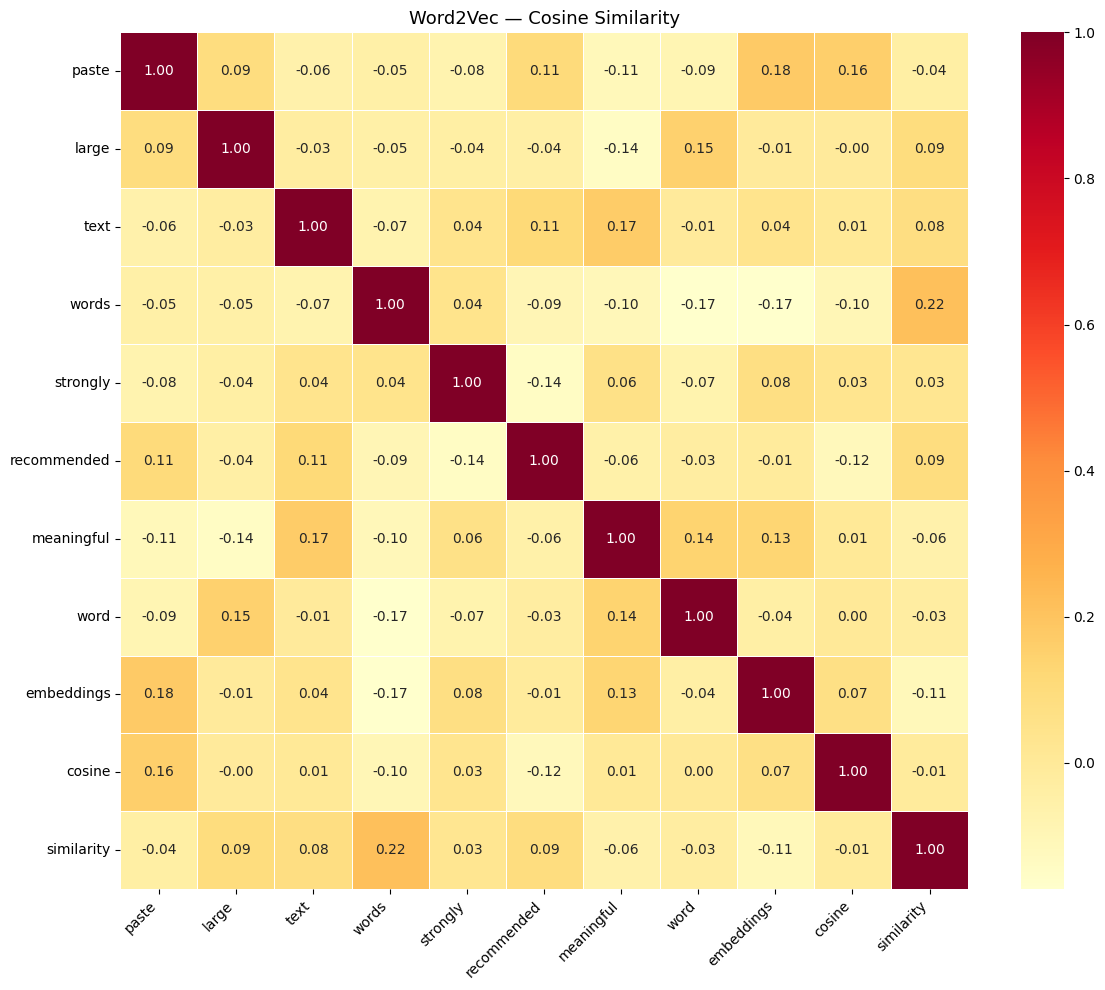

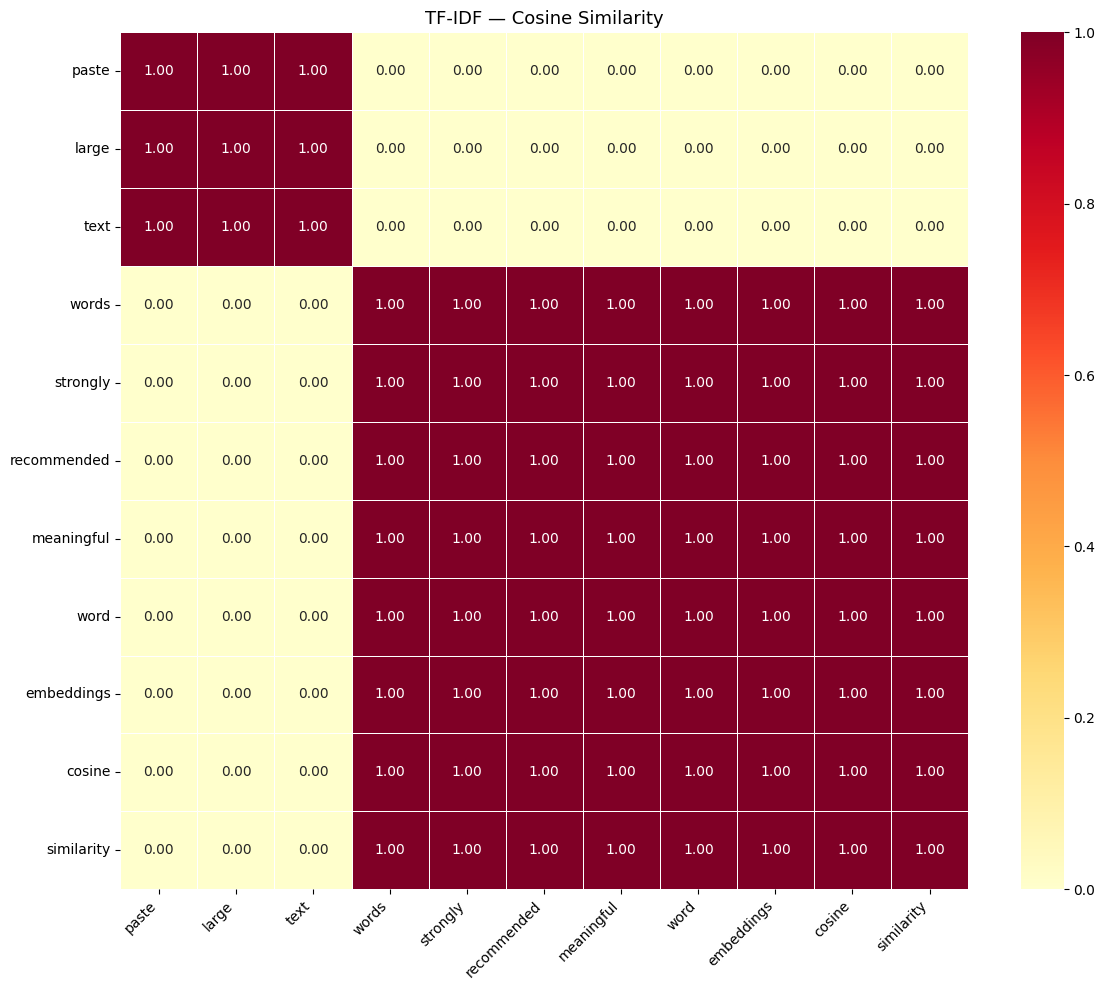

GloVe not loaded — only Word2Vec and TF-IDF matrices shown.


In [39]:
# Select Words + Plot all Matches

import matplotlib.pyplot as plt
import seaborn as sns

def select_top_words(tokens, n=20):
    return [w for w, _ in Counter(tokens).most_common(n)]

def plot_sim_matrix(M, words, title):
    plt.figure(figsize=(12, 10))
    sns.heatmap(M, xticklabels=words, yticklabels=words,
                annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.4)
    plt.title(title, fontsize=13)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

selected_words_l5 = select_top_words(tokens_l5, TOP_WORDS_L5)
print(f"Selected words: {selected_words_l5}")

# Word2Vec
w2v_matrix = build_sim_matrix(
    selected_words_l5,
    lambda w: w2v_l5.wv[w] if w in w2v_l5.wv else None
)
plot_sim_matrix(w2v_matrix, selected_words_l5, "Word2Vec — Cosine Similarity")

# TF-IDF
tfidf_matrix_l5 = build_sim_matrix(
    selected_words_l5,
    lambda w: tfidf_vecs_l5.get(w)
)
plot_sim_matrix(tfidf_matrix_l5, selected_words_l5, "TF-IDF — Cosine Similarity")

# GloVe (only if loaded)
if glove_l5:
    glove_matrix = build_sim_matrix(
        selected_words_l5,
        lambda w: glove_l5.get(w)
    )
    plot_sim_matrix(glove_matrix, selected_words_l5, "GloVe — Cosine Similarity")
else:
    print("GloVe not loaded — only Word2Vec and TF-IDF matrices shown.")

## CNN for Text Classification

In [40]:
# ================================================================
# LAB 6 CONFIG — Edit only this cell
# ================================================================
# CSV must have columns: text, label
# Set None to use NLTK movie_reviews (no internet needed)
FILE_PATH_L6   = None
MAX_WORDS_L6   = 10000
MAX_LEN_L6     = 200
EMB_DIM_L6     = 64
BATCH_SIZE_L6  = 32
EPOCHS_L6      = 5

In [41]:
# Load Dataset
from nltk.corpus import movie_reviews
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

def load_dataset_l6(file_path=None):
    if file_path:
        df     = pd.read_csv(file_path)
        texts  = df['text'].tolist()
        labels = df['label'].tolist()
    else:
        print("Using NLTK movie_reviews corpus.")
        texts, labels = [], []
        for fid in movie_reviews.fileids():
            texts.append(movie_reviews.raw(fid))
            labels.append(movie_reviews.categories(fid)[0])
    print(f"Documents: {len(texts)}  |  Classes: {set(labels)}")
    return texts, labels

texts_l6, raw_labels_l6 = load_dataset_l6(FILE_PATH_L6)

Using NLTK movie_reviews corpus.
Documents: 2000  |  Classes: {'pos', 'neg'}


In [42]:
# Preprocess

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

def preprocess_dl(texts, labels, max_words, max_len):
    le  = LabelEncoder()
    y   = le.fit_transform(labels)

    tok = Tokenizer(num_words=max_words, oov_token="<OOV>")
    tok.fit_on_texts(texts)
    X   = pad_sequences(tok.texts_to_sequences(texts),
                        maxlen=max_len, padding='post', truncating='post')

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"Train: {X_tr.shape}  |  Test: {X_te.shape}  |  Classes: {le.classes_}")
    return X_tr, X_te, y_tr, y_te, tok, le

X_train_l6, X_test_l6, y_train_l6, y_test_l6, tok_l6, le_l6 = preprocess_dl(
    texts_l6, raw_labels_l6, MAX_WORDS_L6, MAX_LEN_L6)

num_classes_l6 = len(le_l6.classes_)
binary_l6      = (num_classes_l6 == 2)

Train: (1600, 200)  |  Test: (400, 200)  |  Classes: ['neg' 'pos']


In [43]:
# Build CNN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, Conv1D, GlobalMaxPooling1D,Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping

def build_cnn(max_words, max_len, emb_dim, filters=128, kernel=5, binary=True, num_classes=2):
    model = Sequential([
        Embedding(max_words, emb_dim, input_length=max_len),
        Conv1D(filters, kernel, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1 if binary else num_classes,  activation='sigmoid' if binary else 'softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy' if binary else 'sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    model.summary()
    return model

cnn_model = build_cnn(MAX_WORDS_L6, MAX_LEN_L6, EMB_DIM_L6,
                    binary=binary_l6, num_classes=num_classes_l6)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 200, 64)           640000    
                                                                 
 conv1d (Conv1D)             (None, 196, 128)          41088     
                                                                 
 global_max_pooling1d (Globa  (None, 128)              0         
 lMaxPooling1D)                                                  
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                        

In [44]:
# Train + Eval

from sklearn.metrics import classification_report, precision_recall_fscore_support

def train_evaluate(model, X_tr, X_te, y_tr, y_te, le,
                epochs, batch_size, name, binary=True):
    es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    model.fit(X_tr, y_tr, epochs=epochs, batch_size=batch_size,
            validation_split=0.1, callbacks=[es], verbose=1)

    pred_prob = model.predict(X_te)
    y_pred    = (pred_prob > 0.5).astype(int).flatten() if binary \
                else pred_prob.argmax(axis=1)

    p, r, f1, _ = precision_recall_fscore_support(y_te, y_pred, average='weighted')
    print(f"\n{'='*55}\nRESULTS: {name}\n{'='*55}")
    print(classification_report(y_te, y_pred, target_names=le.classes_))
    return {'Model': name,
            'Precision': round(p, 4),
            'Recall':    round(r, 4),
            'F1':        round(f1, 4)}

cnn_result = train_evaluate(cnn_model, X_train_l6, X_test_l6,
                            y_train_l6, y_test_l6, le_l6,
                            EPOCHS_L6, BATCH_SIZE_L6,
                            "CNN (128 filters, kernel=5)", binary_l6)

Epoch 1/5
45/45 [==============================] - 13s 11ms/step - loss: 0.6928 - accuracy: 0.5090 - val_loss: 0.6944 - val_accuracy: 0.4062
Epoch 2/5
45/45 [==============================] - 0s 4ms/step - loss: 0.6700 - accuracy: 0.6583 - val_loss: 0.6896 - val_accuracy: 0.6000
Epoch 3/5
45/45 [==============================] - 0s 4ms/step - loss: 0.6257 - accuracy: 0.7993 - val_loss: 0.6850 - val_accuracy: 0.5875
Epoch 4/5
45/45 [==============================] - 0s 4ms/step - loss: 0.4688 - accuracy: 0.9514 - val_loss: 0.6413 - val_accuracy: 0.6438
Epoch 5/5
13/13 [==============================] - 0s 2ms/step

RESULTS: CNN (128 filters, kernel=5)
              precision    recall  f1-score   support

         neg       0.59      0.86      0.70       200
         pos       0.74      0.41      0.52       200

    accuracy                           0.63       400
   macro avg       0.67      0.63      0.61       400
weighted avg       0.67      0.63      0.61       400



## RNN/LSTM/GRU

In [45]:
# ================================================================
# LAB 7 CONFIG — Edit only this cell
# Reuses preprocessed data from Lab 6 — run Lab 6 cells first
# ================================================================
EPOCHS_L7 = 5

# Three configs varying architecture and recurrent units
RNN_CONFIGS = [
    {'type': 'LSTM',      'units': 64,  'name': 'LSTM  (64 units)'},
    {'type': 'GRU',       'units': 128, 'name': 'GRU   (128 units)'},
    {'type': 'SimpleRNN', 'units': 64,  'name': 'SimpleRNN (64 units)'},
]

In [46]:
#Build RNN Models

from tensorflow.keras.layers import LSTM, GRU, SimpleRNN

def build_rnn_model(rnn_type, units, max_words, max_len, emb_dim,
                    binary=True, num_classes=2):
    layer_map = {'LSTM': LSTM, 'GRU': GRU, 'SimpleRNN': SimpleRNN}
    RNNLayer  = layer_map[rnn_type]

    model = Sequential([
        Embedding(max_words, emb_dim, input_length=max_len),
        RNNLayer(units, dropout=0.2, recurrent_dropout=0.2),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1 if binary else num_classes,
            activation='sigmoid' if binary else 'softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy' if binary else 'sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [47]:
# Train All + Comparison Table

all_results_l7 = [cnn_result]  # carry CNN result from Lab 6

for cfg in RNN_CONFIGS:
    print(f"\n{'='*60}\nTraining: {cfg['name']}\n{'='*60}")
    model = build_rnn_model(
        cfg['type'], cfg['units'],
        MAX_WORDS_L6, MAX_LEN_L6, EMB_DIM_L6,
        binary=binary_l6, num_classes=num_classes_l6
    )
    model.summary()
    result = train_evaluate(
        model,
        X_train_l6, X_test_l6,
        y_train_l6, y_test_l6,
        le_l6,
        EPOCHS_L7, BATCH_SIZE_L6,
        cfg['name'], binary_l6
    )
    all_results_l7.append(result)

# Final comparison table
results_df_l7 = pd.DataFrame(all_results_l7)
print("\n" + "=" * 60)
print("MODEL COMPARISON: CNN vs RNN Variants")
print("=" * 60)
print(results_df_l7.to_string(index=False))


Training: LSTM  (64 units)
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 200, 64)           640000    
                                                                 
 lstm (LSTM)                 (None, 64)                33024     
                                                                 
 dense_2 (Dense)             (None, 64)                4160      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                                 
Total params: 677,249
Trainable params: 677,249
Non-trainable params: 0
_________________________________________________________________
Epoch 1/5
45/45 [===

## Text Summarization (LSTM + Attention)

In [48]:
# ================================================================
# LAB 8 CONFIG — Edit only this cell
# CSV must have columns: text, summary
# None = use NLTK Reuters (first sentence as pseudo-summary)
# ================================================================
FILE_PATH_L8    = None
VOCAB_SIZE_L8   = 8000
LATENT_DIM_L8   = 256
EMB_DIM_L8      = 128
EPOCHS_L8       = 10
BATCH_SIZE_L8   = 64

# 3 experiments varying one parameter at a time
EXPERIMENTS_L8 = [
    {'max_text': 80,  'max_sum': 15, 'enc_layers': 1, 'name': 'Baseline'},
    {'max_text': 120, 'max_sum': 25, 'enc_layers': 1, 'name': 'Longer text & summary'},
    {'max_text': 80,  'max_sum': 15, 'enc_layers': 2, 'name': 'Stacked encoder (2 LSTM)'},
]

In [49]:
# Load Data

def load_data_l8(file_path=None, n_samples=2000):
    if file_path:
        df       = pd.read_csv(file_path)
        texts    = df['text'].tolist()
        summaries = df['summary'].tolist()
    else:
        from nltk.corpus import reuters
        nltk.download('reuters', quiet=True)
        texts, summaries = [], []
        for fid in reuters.fileids():
            raw   = reuters.raw(fid)
            sents = nltk.sent_tokenize(raw)
            if len(sents) >= 3:
                summaries.append(sents[0])
                texts.append(" ".join(sents[1:min(10, len(sents))]))
            if len(texts) >= n_samples:
                break
        print(f"Reuters: {len(texts)} document-summary pairs loaded.")

    # Add start/end tokens for the decoder
    summaries = ['<start> ' + s + ' <end>' for s in summaries]
    print(f"Sample text    : {texts[0][:80]}...")
    print(f"Sample summary : {summaries[0][:80]}...")
    return texts, summaries

texts_l8, summaries_l8 = load_data_l8(FILE_PATH_L8)

Reuters: 2000 document-summary pairs loaded.
Sample text    : They told Reuter correspondents in Asian capitals a U.S.
  Move against Japan mi...
Sample summary : <start> ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RIFT
  Mounting trade fricti...


In [50]:
# Preprocessing

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

def preprocess_summ(texts, summaries, max_text, max_sum, vocab_size):
    FILTERS = '!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n'

    x_tok = Tokenizer(num_words=vocab_size, oov_token='<OOV>', filters=FILTERS)
    x_tok.fit_on_texts(texts)
    X = pad_sequences(x_tok.texts_to_sequences(texts),
                    maxlen=max_text, padding='post', truncating='post')

    y_tok = Tokenizer(num_words=vocab_size, oov_token='<OOV>', filters=FILTERS)
    y_tok.fit_on_texts(summaries)
    Y = pad_sequences(y_tok.texts_to_sequences(summaries),
                    maxlen=max_sum, padding='post', truncating='post')

    x_voc = min(vocab_size, len(x_tok.word_index) + 1)
    y_voc = min(vocab_size, len(y_tok.word_index) + 1)
    print(f"X: {X.shape}  x_vocab={x_voc}  |  Y: {Y.shape}  y_vocab={y_voc}")
    return X, Y, x_tok, y_tok, x_voc, y_voc

In [51]:
# Model (Encoder+Decoder+Attention)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, LSTM, Dense,Concatenate, Attention, TimeDistributed)

def build_seq2seq(x_voc, y_voc, max_text, latent_dim, emb_dim, enc_layers=1):
    # ---- ENCODER ----
    enc_in  = Input(shape=(max_text,), name='enc_input')
    enc_emb = Embedding(x_voc, emb_dim, trainable=True)(enc_in)

    enc_out = enc_emb
    for i in range(enc_layers - 1):
        enc_out, _, _ = LSTM(latent_dim, return_sequences=True,
        return_state=True, name=f'enc_lstm_{i}')(enc_out)

    enc_out, state_h, state_c = LSTM(latent_dim, return_sequences=True,return_state=True, name='enc_lstm_final')(enc_out)

    # ---- DECODER ----
    dec_in  = Input(shape=(None,), name='dec_input')
    dec_emb = Embedding(y_voc, emb_dim, trainable=True)(dec_in)

    dec_out, _, _ = LSTM(latent_dim, return_sequences=True, return_state=True,name='dec_lstm')(dec_emb, initial_state=[state_h, state_c])

    # ---- ATTENTION (Luong dot-product via Keras) ----
    attn_out = Attention(name='attention')([dec_out, enc_out])

    merged   = Concatenate(axis=-1, name='merge')([dec_out, attn_out])
    output   = TimeDistributed(Dense(y_voc, activation='softmax'), name='output')(merged)

    model = Model([enc_in, dec_in], output)
    model.compile(optimizer='rmsprop',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return model

In [52]:
# Train

from sklearn.model_selection import train_test_split

def train_summ_model(model, X, Y, epochs, batch_size):
    # Teacher forcing: feed Y[:-1] as decoder input, predict Y[1:]
    dec_in     = Y[:, :-1]
    dec_target = Y[:, 1:].reshape(*Y[:, 1:].shape, 1)  # sparse CE needs shape (batch, t, 1)

    X_tr, X_te, dec_in_tr, dec_in_te, tgt_tr, tgt_te = train_test_split(
        X, dec_in, dec_target, test_size=0.1, random_state=42)

    es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    history = model.fit(
        [X_tr, dec_in_tr], tgt_tr,
        epochs=epochs, batch_size=batch_size,
        validation_data=([X_te, dec_in_te], tgt_te),
        callbacks=[es], verbose=1
    )
    return model, history, X_te, dec_in_te, tgt_te

In [53]:
# Rouge Evalution 

def evaluate_rouge(model, X_te, dec_in_te, tgt_te, y_tok, top_k=100):
    try:
        from rouge_score import rouge_scorer as rs_mod
        scorer   = rs_mod.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
        use_rouge = True
    except ImportError:
        print("Install rouge_score: pip install rouge-score")
        use_rouge = False
        return {}

    idx2word = {v: k for k, v in y_tok.word_index.items()}

    def decode(ids):
        return ' '.join(idx2word.get(i, '') for i in ids
                        if i not in [0] and idx2word.get(i, '') not in
                        ['<start>', '<end>', '<OOV>'])

    preds    = model.predict([X_te[:top_k], dec_in_te[:top_k]]).argmax(axis=-1)
    r1, r2, rL = [], [], []
    for i in range(top_k):
        ref = decode(tgt_te[i, :, 0].astype(int))
        hyp = decode(preds[i])
        if ref.strip() and hyp.strip():
            s = scorer.score(ref, hyp)
            r1.append(s['rouge1'].fmeasure)
            r2.append(s['rouge2'].fmeasure)
            rL.append(s['rougeL'].fmeasure)

    results = {'ROUGE-1': round(sum(r1)/len(r1), 4) if r1 else 0,'ROUGE-2': round(sum(r2)/len(r2), 4) if r2 else 0,'ROUGE-L': round(sum(rL)/len(rL), 4) if rL else 0}
    print(f"ROUGE-1: {results['ROUGE-1']}  ROUGE-2: {results['ROUGE-2']}  ROUGE-L: {results['ROUGE-L']}")
    return results

In [54]:
# Run all 3 Exp

all_summ_results = []

for exp in EXPERIMENTS_L8:
    print(f"\n{'='*65}\nEXPERIMENT: {exp['name']}")
    print(f"  max_text={exp['max_text']}  max_sum={exp['max_sum']}  enc_layers={exp['enc_layers']}")
    print('=' * 65)

    X, Y, x_tok, y_tok, x_voc, y_voc = preprocess_summ(
        texts_l8, summaries_l8,
        exp['max_text'], exp['max_sum'], VOCAB_SIZE_L8
    )
    model = build_seq2seq(x_voc, y_voc, exp['max_text'],
                        LATENT_DIM_L8, EMB_DIM_L8, exp['enc_layers'])
    model.summary()

    model, history, X_te, dec_in_te, tgt_te = train_summ_model(
        model, X, Y, EPOCHS_L8, BATCH_SIZE_L8)

    rouge = evaluate_rouge(model, X_te, dec_in_te, tgt_te, y_tok)

    all_summ_results.append({
        'Experiment'  : exp['name'],
        'max_text_len': exp['max_text'],
        'max_sum_len' : exp['max_sum'],
        'enc_layers'  : exp['enc_layers'],
        **rouge
    })

print("\n" + "=" * 70)
print("SUMMARIZATION — ALL EXPERIMENT RESULTS")
print("=" * 70)
print(pd.DataFrame(all_summ_results).to_string(index=False))


EXPERIMENT: Baseline
  max_text=80  max_sum=15  enc_layers=1
X: (2000, 80)  x_vocab=8000  |  Y: (2000, 15)  y_vocab=8000
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 enc_input (InputLayer)         [(None, 80)]         0           []                               
                                                                                                  
 dec_input (InputLayer)         [(None, None)]       0           []                               
                                                                                                  
 embedding_4 (Embedding)        (None, 80, 128)      1024000     ['enc_input[0][0]']              
                                                                                                  
 embedding_5 (Embedding)        (None, None, 128)    1024000     ['dec_